# Raman Cell Phenotyping

Hyperspectral unmixing of volumetric Raman spectroscopy data to analyse the biomolecular composition of THP-1 cells.

**Problem**: Each voxel in a Raman volume contains a spectrum that is a linear mixture of pure-component signatures (endmembers). The goal is to recover the endmember spectra and map their spatial abundances.

**Method**: Preprocessing (crop, despike, denoise, baseline correct, normalise) followed by N-FINDR endmember extraction and FCLS abundance estimation.

**Data**: Kallepitis et al., *Nat Commun* 8, 14843 (2017).

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

## 1. Load precomputed results

We load the reference outputs (endmembers, abundance maps, preprocessed volume) generated by `main.py`. This avoids re-running the expensive preprocessing and unmixing steps.

In [2]:
ref_dir = "../evaluation/reference_outputs"

# Preprocessed volume
processed = np.load(f"{ref_dir}/preprocessed_volume.npy")
proc_axis = np.load(f"{ref_dir}/preprocessed_axis.npy")

# Endmembers
em_data = np.load(f"{ref_dir}/endmembers.npz")
endmembers = [em_data[f"endmember_{i}"] for i in range(5)]

# Abundance maps
am_data = np.load(f"{ref_dir}/abundance_maps.npz")
abundance_maps = [am_data[f"abundance_{i}"] for i in range(5)]

# Raw data for comparison
raw = np.load("../data/raw_data.npz")
raw_volume = raw["spectral_volume"][0]
raw_axis = raw["spectral_axis"]

print(f"Raw volume: {raw_volume.shape}, axis: {raw_axis[0]:.0f}-{raw_axis[-1]:.0f} cm-1")
print(f"Processed volume: {processed.shape}, axis: {proc_axis[0]:.0f}-{proc_axis[-1]:.0f} cm-1")
print(f"Endmembers: {len(endmembers)}, each {endmembers[0].shape}")
print(f"Abundance maps: {len(abundance_maps)}, each {abundance_maps[0].shape}")

Raw volume: (40, 40, 10, 1600), axis: -136-3671 cm-1
Processed volume: (40, 40, 10, 426), axis: 702-1798 cm-1
Endmembers: 5, each (426,)
Abundance maps: 5, each (40, 40, 10)


## 2. Raw vs preprocessed spectra

The preprocessing pipeline applies five sequential steps:
1. **Spectral cropping** to the fingerprint region (700-1800 cm$^{-1}$)
2. **Whitaker-Hayes despiking** to remove cosmic-ray artefacts
3. **Savitzky-Golay smoothing** for noise reduction
4. **ASLS baseline correction** to remove fluorescence background
5. **Global min-max normalisation** to [0, 1]

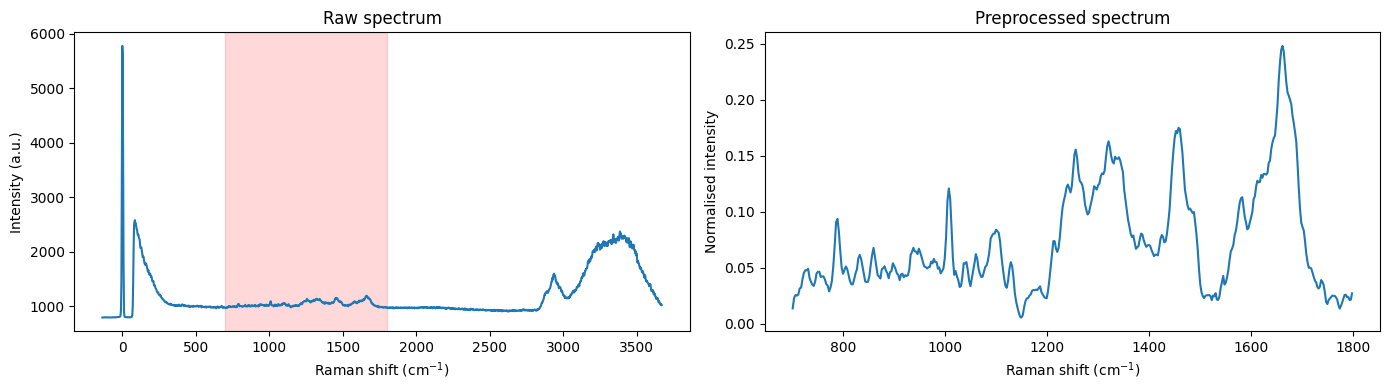

In [3]:
px, py, pz = 15, 25, 5

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw spectrum
axes[0].plot(raw_axis, raw_volume[px, py, pz, :])
axes[0].axvspan(700, 1800, alpha=0.15, color='red')
axes[0].set_xlabel(r"Raman shift (cm$^{-1}$)")
axes[0].set_ylabel("Intensity (a.u.)")
axes[0].set_title("Raw spectrum")

# Preprocessed spectrum
axes[1].plot(proc_axis, processed[px, py, pz, :])
axes[1].set_xlabel(r"Raman shift (cm$^{-1}$)")
axes[1].set_ylabel("Normalised intensity")
axes[1].set_title("Preprocessed spectrum")

plt.tight_layout()
plt.show()

## 3. Spectral band images

Slicing the preprocessed volume at specific wavenumbers reveals the spatial distribution of biomolecular components. Key diagnostic bands:
- **789 cm$^{-1}$**: DNA (cytosine ring breathing)
- **1008 cm$^{-1}$**: Protein (phenylalanine)
- **1303 cm$^{-1}$**: Lipids (CH$_2$ twist)

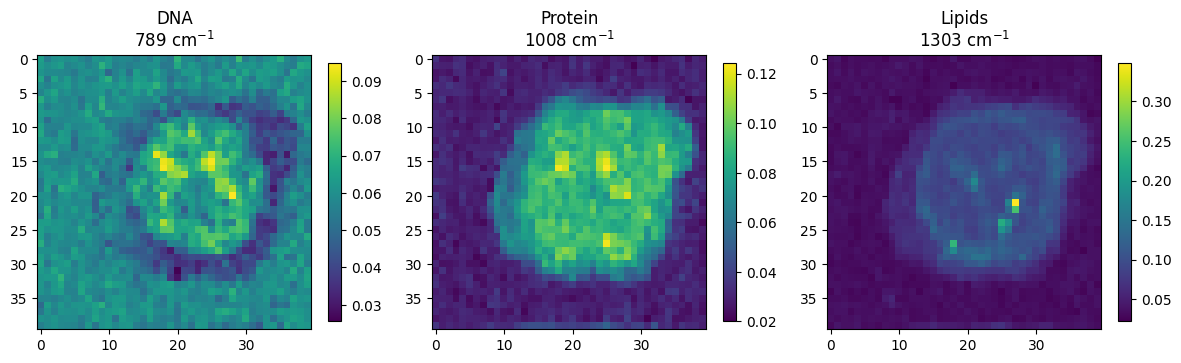

In [4]:
bands = [789, 1008, 1303]
band_labels = ["DNA\n789 cm$^{-1}$", "Protein\n1008 cm$^{-1}$", "Lipids\n1303 cm$^{-1}$"]
layer = 5

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band, label in zip(axes, bands, band_labels):
    band_idx = np.argmin(np.abs(proc_axis - band))
    im = ax.imshow(processed[:, :, layer, band_idx], cmap="viridis")
    ax.set_title(label)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

## 4. Endmember spectra

N-FINDR extracted 5 endmembers. We select 4 that correspond to biologically meaningful components and label them by inspecting their characteristic Raman peaks.

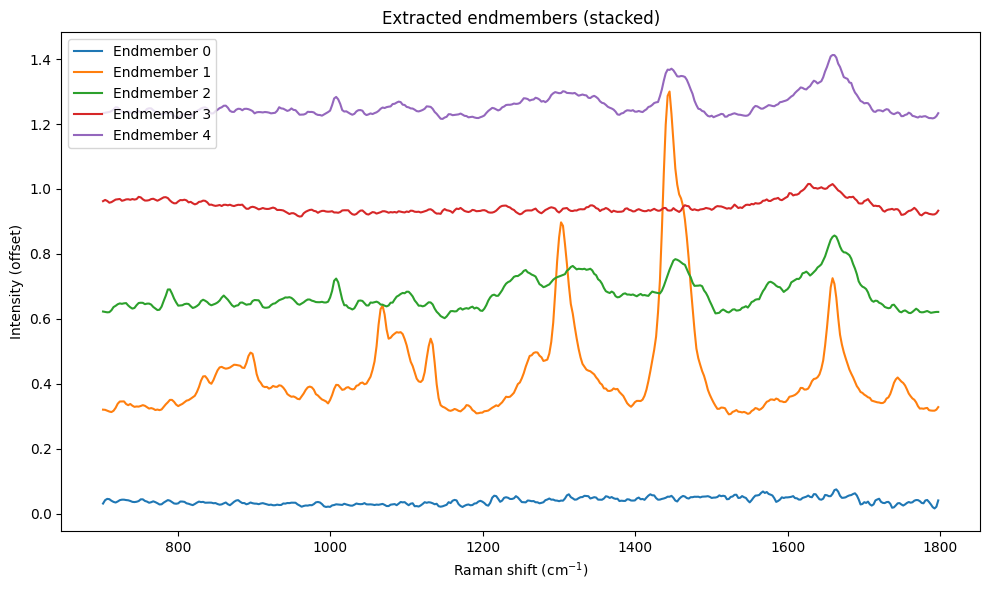

In [5]:
# All 5 endmembers (stacked)
fig, ax = plt.subplots(figsize=(10, 6))
for i, em in enumerate(endmembers):
    ax.plot(proc_axis, em + i * 0.3, label=f"Endmember {i}")
ax.set_xlabel(r"Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (offset)")
ax.set_title("Extracted endmembers (stacked)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Selected endmembers with peak annotations
selected_indices = [2, 0, 3, 1]
labels = ["Lipids", "Nucleus", "Cytoplasm", "Background"]
selected_endmembers = [endmembers[i] for i in selected_indices]

fig, ax = plt.subplots(figsize=(10, 6))
for i, (em, lbl) in enumerate(zip(selected_endmembers, labels)):
    ax.plot(proc_axis, em + i * 0.3, label=lbl)

# Mark characteristic peaks
peaks = [789, 1008, 1066, 1134, 1303, 1443, 1747]
for p in peaks:
    ax.axvline(p, linestyle="--", color="black", alpha=0.3, zorder=0)
    ax.text(p + 5, ax.get_ylim()[1] * 0.95, str(p), fontsize=7, rotation=90, va="top")

ax.set_xlabel(r"Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (offset)")
ax.set_title("Selected endmembers with characteristic peaks")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Abundance maps

The FCLS-derived abundance maps show where each biomolecular component is concentrated in the cell at z-layer 5.

In [ ]:
selected_abundances = [abundance_maps[i] for i in selected_indices]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, amap, lbl in zip(axes, selected_abundances, labels):
    ax.imshow(amap[:, :, 5], cmap="viridis")
    ax.set_title(lbl)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Merged false-colour reconstruction

Overlaying the abundance maps with distinct colours produces a false-colour image showing the spatial organisation of the cell: nucleus (blue) in the centre, cytoplasm (green) forming a ring around it, lipids (purple) in droplets, and background (yellow) outside.

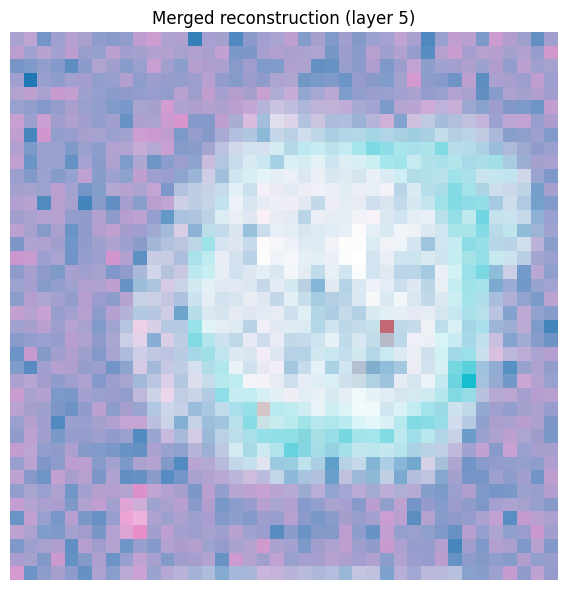

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

cmap_vals = plt.colormaps["tab10"](np.linspace(0, 1, len(selected_abundances)))
white = [1, 1, 1, 0]

order = ["Background", "Cytoplasm", "Nucleus", "Lipids"]
for lbl in order:
    i = labels.index(lbl)
    cmap_i = LinearSegmentedColormap.from_list("", [white, cmap_vals[i]])
    ax.imshow(selected_abundances[i][:, :, 5], cmap=cmap_i)

ax.set_title("Merged reconstruction (layer 5)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Reconstruction quality

We evaluate the linear mixing reconstruction error: how well the endmembers and abundances explain the observed spectra.

In [9]:
from src.physics_model import forward, reconstruction_error

flat_obs = processed.reshape(-1, processed.shape[-1])
endmember_matrix = np.stack(endmembers)
flat_abund = np.stack([a.ravel() for a in abundance_maps], axis=-1)

rmse = reconstruction_error(flat_obs, endmember_matrix, flat_abund)
print(f"Reconstruction RMSE: {rmse:.6f}")
print(f"Data range: [{flat_obs.min():.4f}, {flat_obs.max():.4f}]")
print(f"Relative RMSE: {rmse / (flat_obs.max() - flat_obs.min()):.4f}")

Reconstruction RMSE: 0.006310
Data range: [0.0000, 1.0000]
Relative RMSE: 0.0063


## Running from scratch

To reproduce the full pipeline from raw data (takes several minutes):

```python
# from src.preprocessing import load_observation, preprocess_volume
# from src.solvers import unmix
# import random
#
# random.seed(12345)
# obs = load_observation("../data")
# volume = obs["spectral_volume"]
# axis = obs["spectral_axis"]
# processed, proc_axis = preprocess_volume(volume, axis)
# abundance_maps, endmembers = unmix(processed, n_endmembers=5)
```